# 01 — Exploratory analysis

Establishes the shape of the problem before any modelling. Four things this notebook needs to settle:

1. **How extreme the imbalance is**, and why accuracy is therefore useless here (proposal §3.5).
2. **Where fraud lives** — it appears in TRANSFER and CASH_OUT and nowhere else, which means three of five transaction types carry no positive class at all.
3. **Whether time carries signal** — legitimate volume collapses overnight while fraud does not, so the fraud *rate* spikes in the small hours even though the count does not.
4. **What the fraud mechanism looks like** — the account-drain signature that makes PaySim tractable, and which notebook 02 then interrogates as a possible simulator artifact.

Every table is written to `results/` for direct import into the report; every figure to `figures/` as both vector PDF and PNG.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import analysis as A
from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import viz

viz.apply_house_style()
df = D.load()
summary = D.summarise(df)
print(f"{len(df):,} transactions loaded")

6,362,620 transactions loaded


## The imbalance

Deliberately **not** a chart. A bar of 99.87 against 0.13 conveys nothing the number does not say better, and a pie chart would be worse. The figure below is three hero numbers.

The third one is the whole study in a single value: at this prevalence a model that predicts "legitimate" for every transaction scores 99.87% accuracy. That is the accuracy paradox the proposal's section 3.5 describes, and it is why every metric here is either threshold-free (PR-AUC) or explicitly risk-weighted.

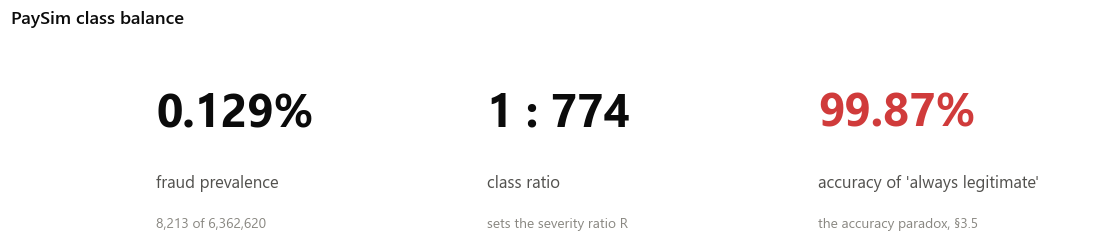

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.4))

viz.stat_tile(axes[0], f"{summary['prevalence']:.3%}", "fraud prevalence",
              f"{summary['n_fraud']:,} of {summary['n_transactions']:,}")
viz.stat_tile(axes[1], f"1 : {summary['imbalance_ratio']:.0f}", "class ratio",
              "sets the severity ratio R")
viz.stat_tile(axes[2], f"{1 - summary['prevalence']:.2%}", "accuracy of 'always legitimate'",
              "the accuracy paradox, section 3.5", accent=viz.STATUS["critical"])

fig.suptitle("PaySim class balance", x=0.005, ha="left", fontsize=12, fontweight="semibold")
viz.save_figure(fig, "01_class_balance")
plt.show()

## Where fraud lives

Two panels rather than one chart with two y-axes. Volume and fraud rate differ by three orders of magnitude, and overlaying them on twin axes would let the choice of scale dictate which story the reader sees the single most common way a chart like this misleads.

In [3]:
by_type = A.fraud_rate_by_type(df)
E.save_results(by_type.to_dict("records"), "01_fraud_by_type")
by_type

,type,n_transactions,n_fraud,fraud_rate,share_of_volume,share_of_fraud
0,CASH_OUT,2237500,4116,0.001840,0.351663,0.501157
1,PAYMENT,2151495,0,0.000000,0.338146,0.000000
2,CASH_IN,1399284,0,0.000000,0.219923,0.000000
3,TRANSFER,532909,4097,0.007688,0.083756,0.498843
4,DEBIT,41432,0,0.000000,0.006512,0.000000


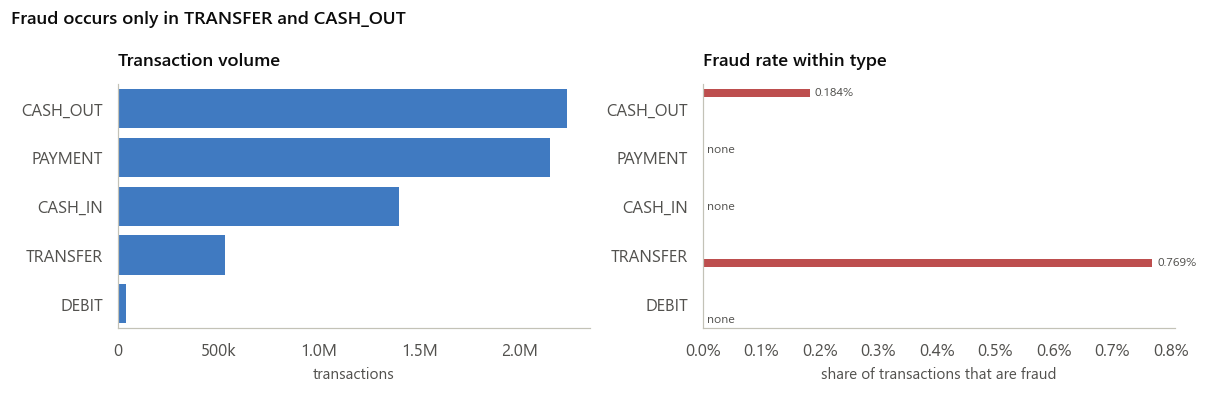

In [4]:
fig, (ax_volume, ax_rate) = plt.subplots(1, 2, figsize=(11, 3.6))
order = by_type["type"].tolist()

sns.barplot(by_type, x="n_transactions", y="type", order=order,
            color=viz.CATEGORICAL[0], ax=ax_volume)
ax_volume.set(title="Transaction volume", xlabel="transactions", ylabel="")
ax_volume.xaxis.set_major_formatter(viz.compact_number)

# Fraud-bearing types take the accent; the rest recede. Colour follows the
# entity's meaning, not its rank.
rate_colors = [viz.STATUS["critical"] if t in C.FRAUD_BEARING_TYPES else viz.INK["baseline"]
               for t in order]
sns.barplot(by_type, x="fraud_rate", y="type", order=order,
            hue="type", hue_order=order, palette=rate_colors, legend=False, ax=ax_rate)
ax_rate.set(title="Fraud rate within type", xlabel="share of transactions that are fraud", ylabel="")
ax_rate.xaxis.set_major_formatter(viz.percent_formatter(1))
# The values are proportions but the axis reads as a percentage, so the
# labels must too -- otherwise a 0.77% bar prints as "0.008".
viz.value_labels(ax_rate, fmt=lambda v: f"{v:.3%}" if v > 0 else "none")

for ax in (ax_volume, ax_rate):
    viz.despine(ax)
    ax.grid(axis="y", visible=False)

fig.suptitle("Fraud occurs only in TRANSFER and CASH_OUT",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "01_fraud_by_type")
plt.show()

## Amount distribution

An ECDF rather than a KDE. A kernel density estimate on a log-scaled, heavily skewed variable invents smoothness the data does not have, and its bandwidth choice would visibly change the story. The ECDF is exact: read any point as "this share of transactions were at or below this amount."

C:\Users\siphe\source\repos\CodeHermez\momo-fraud-supervised-ml\src\momo_fraud\viz.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(path, **kwargs)


C:\Users\siphe\source\repos\CodeHermez\momo-fraud-supervised-ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


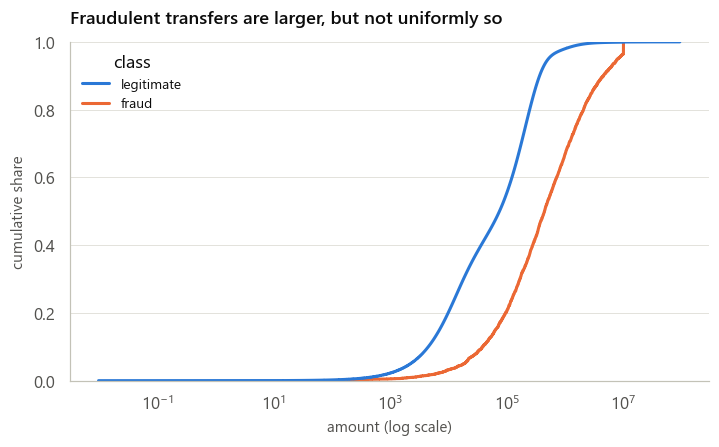

,class,n,mean,std,p25,p50,p75,p95,p99,max
0,legitimate,6354407,1.781970e+05,596237.0,13368.395020,74684.71875,2.083648e+05,5.156104e+05,1.586064e+06,92445520.0
1,fraud,8213,1.467967e+06,2404253.0,127091.328125,441423.43750,1.517772e+06,8.006429e+06,1.000000e+07,10000000.0


In [5]:
amounts = A.amount_summary(df)
E.save_results(amounts.to_dict("records"), "01_amount_summary")

fig, ax = plt.subplots(figsize=(7.5, 4))
labelled = df.assign(**{"class": np.where(df[C.TARGET] == 1, "fraud", "legitimate")})

sns.ecdfplot(labelled[labelled["amount"] > 0], x="amount", hue="class",
             palette=viz.CLASS_COLORS, log_scale=True, ax=ax)
ax.set(title="Fraudulent transfers are larger, but not uniformly so",
       xlabel="amount (log scale)", ylabel="cumulative share")
viz.despine(ax)

viz.save_figure(fig, "01_amount_ecdf")
plt.show()
amounts

## Time of day

The most useful insight in this notebook, and it only appears when both panels are read together: the **count** of fraud is roughly flat across the day, but legitimate volume collapses overnight — so the fraud **rate** spikes in the small hours. A model given only the raw count would learn nothing from the hour; given the rate, the hour becomes genuinely informative.

This is why `hour` is engineered as a feature rather than dropped along with `step`.

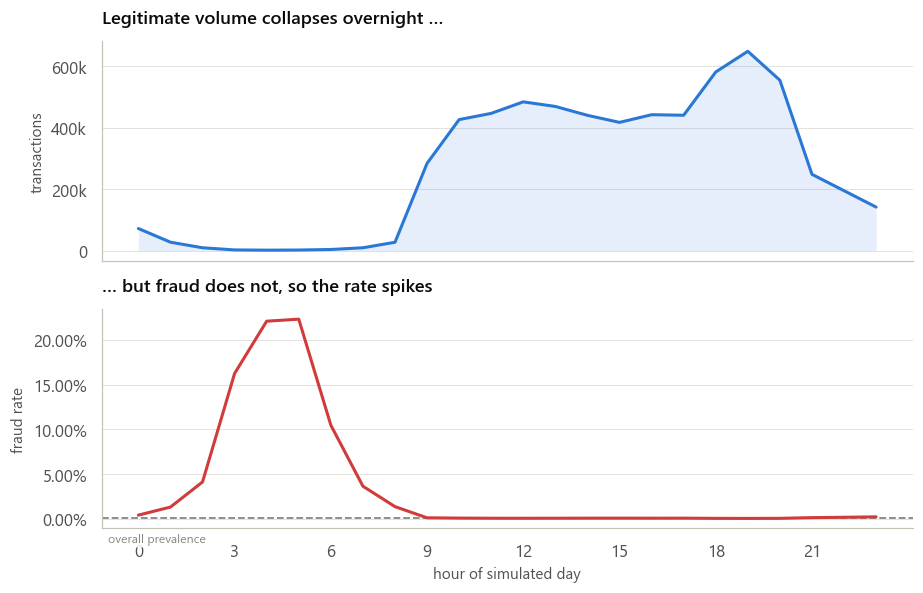

volume    peak 647,814 at hour 19 | trough 1,241 at hour 4 | ratio 522.0x
fraud rate range 0.053% – 22.303% (overall 0.129%)


In [6]:
hourly = A.hourly_profile(df)
E.save_results(hourly.to_dict("records"), "01_hourly_profile")

fig, (ax_volume, ax_rate) = plt.subplots(2, 1, figsize=(8.5, 5.5), sharex=True)

ax_volume.plot(hourly["hour"], hourly["n_transactions"], color=viz.CATEGORICAL[0])
ax_volume.fill_between(hourly["hour"], hourly["n_transactions"], alpha=0.12,
                       color=viz.CATEGORICAL[0])
ax_volume.set(title="Legitimate volume collapses overnight …", ylabel="transactions")
ax_volume.yaxis.set_major_formatter(viz.compact_number)

ax_rate.plot(hourly["hour"], hourly["fraud_rate"], color=viz.STATUS["critical"])
ax_rate.set(title="… but fraud does not, so the rate spikes",
            xlabel="hour of simulated day", ylabel="fraud rate")
ax_rate.yaxis.set_major_formatter(viz.percent_formatter(2))
viz.annotate_reference(ax_rate, summary["prevalence"], "overall prevalence",
                       axis="y", side="left", below=True)

for ax in (ax_volume, ax_rate):
    viz.despine(ax)
ax_rate.set_xticks(range(0, 24, 3))

fig.tight_layout()
viz.save_figure(fig, "01_hourly_profile")
plt.show()

# The titles above assert a pattern; print the numbers so the claim is checkable
# rather than assumed. On the real file the trough/peak ratio is dramatic.
peak, trough = hourly["n_transactions"].max(), hourly["n_transactions"].min()
print(f"volume    peak {peak:,} at hour {hourly.loc[hourly['n_transactions'].idxmax(), 'hour']}"
      f" | trough {trough:,} at hour {hourly.loc[hourly['n_transactions'].idxmin(), 'hour']}"
      f" | ratio {peak / max(trough, 1):.1f}x")
print(f"fraud rate range {hourly['fraud_rate'].min():.3%} – {hourly['fraud_rate'].max():.3%}"
      f" (overall {summary['prevalence']:.3%})")

## The fraud mechanism

PaySim's fraud agents take over an account and empty it, so for fraudulent transactions the amount equals the origin's opening balance almost exactly. Points sit on the identity line.

This is the strongest signal in the dataset — and it is a property of the *simulator*, not of mobile money. Notebook 02 quantifies how much of the achievable performance rests on it.

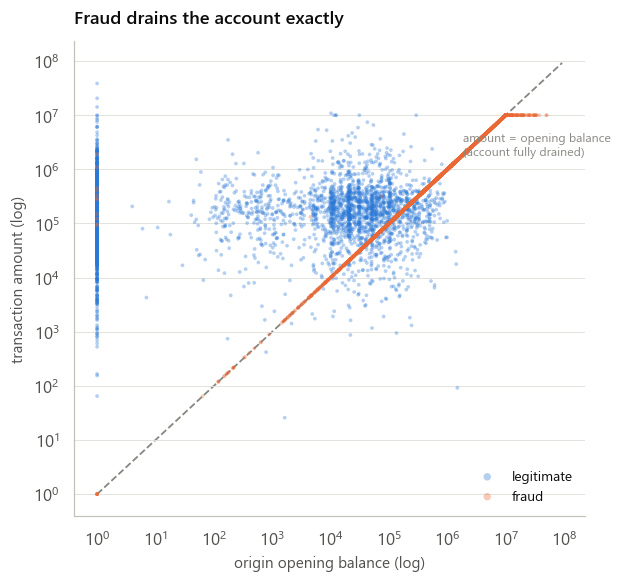

In [7]:
sample_n = 4000
rng = np.random.default_rng(C.RANDOM_SEED)

fraud = df[df[C.TARGET] == 1]
legit = df[(df[C.TARGET] == 0) & (df["type"].isin(C.FRAUD_BEARING_TYPES))]
legit = legit.iloc[rng.choice(len(legit), size=min(sample_n, len(legit)), replace=False)]
fraud_s = fraud.iloc[rng.choice(len(fraud), size=min(sample_n, len(fraud)), replace=False)]

fig, ax = plt.subplots(figsize=(6, 5.6))
for subset, label in ((legit, "legitimate"), (fraud_s, "fraud")):
    ax.scatter(subset["oldbalanceOrg"].clip(lower=1), subset["amount"].clip(lower=1),
               s=6, alpha=0.35, color=viz.CLASS_COLORS[label], label=label,
               edgecolors="none")

limits = [1, max(df["oldbalanceOrg"].max(), df["amount"].max())]
ax.plot(limits, limits, color=viz.INK["muted"], linestyle="--", linewidth=1.2, zorder=0)
ax.annotate("amount = opening balance\n(account fully drained)", xy=(limits[1] * 0.02, limits[1] * 0.02),
            fontsize=8, color=viz.INK["muted"], ha="left")

ax.set(xscale="log", yscale="log", xlabel="origin opening balance (log)",
       ylabel="transaction amount (log)",
       title="Fraud drains the account exactly")
ax.legend(markerscale=2)
viz.despine(ax)

viz.save_figure(fig, "01_drain_signature")
plt.show()

## Feature correlations

A single-hue sequential ramp for magnitude and a diverging blue↔red ramp for the signed correlations — never a rainbow, and never a hue at the midpoint, so "no correlation" reads as neutral rather than as a colour of its own.

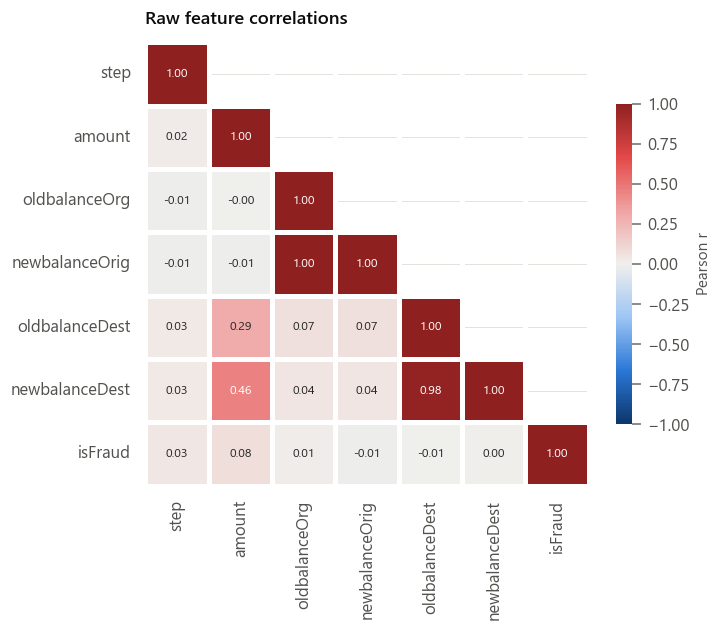

In [8]:
numeric = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
           "oldbalanceDest", "newbalanceDest", C.TARGET]
corr = df[numeric].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.4))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=viz.diverging_cmap(), center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=2, linecolor="white", square=True,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Raw feature correlations")

viz.save_figure(fig, "01_correlation_heatmap")
plt.show()

In [ ]:
print("Written to results/: 01_fraud_by_type, 01_amount_summary, 01_hourly_profile")
print("Written to figures/: class_balance, fraud_by_type, amount_ecdf, hourly_profile,")
print("                     drain_signature, correlation_heatmap")
print("\nNext: 02_leakage_audit.ipynb  which decides what is admissible as a feature.")

Written to results/: 01_fraud_by_type, 01_amount_summary, 01_hourly_profile
Written to figures/: class_balance, fraud_by_type, amount_ecdf, hourly_profile,
                     drain_signature, correlation_heatmap

Next: 02_leakage_audit.ipynb — which decides what is admissible as a feature.
